# Simple Linear Regression — From Scratch
### Price per m² ~ Distance to Nearest Subway Station

This notebook guides you through building a linear regression **manually**, step by step,
before comparing with `statsmodels`.

| Step | Method |
|------|--------|
| 1 | Grid search with `np.linspace` (coarse → refined) |
| 2 | Gradient Descent |
| 3 | Residual analysis — SE, t-stat, p-value |
| 4 | Diagnostic plots (residuals vs fitted, distribution) |

---


## 0 · Setup and Data

For this we will use our filtered dataset, with all appartments  and their price per square plus distances. from previous work, export a parquet that you can reuse here.


In [1]:
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import stats
from shapely.geometry import Point

## TODO put your own parquet file (onesquaremeter filtered with z-score < 5 and distances < 35_000 )
gdf = gpd.read_parquet('C:\\Users\\pc\\Documents\\Data analysis\\Regression linear\\doc.parquet')


### TO DO
- create a variable X with all the `distances` values
- create a variable Y with all the `onesquaremeter` values

In [2]:
# ── Extract arrays (the only two columns we need) ──
X = gdf.distances.values  # predictor
y = gdf.onesquaremeter.values # response
n = len(X)

visualize the scatter plot here

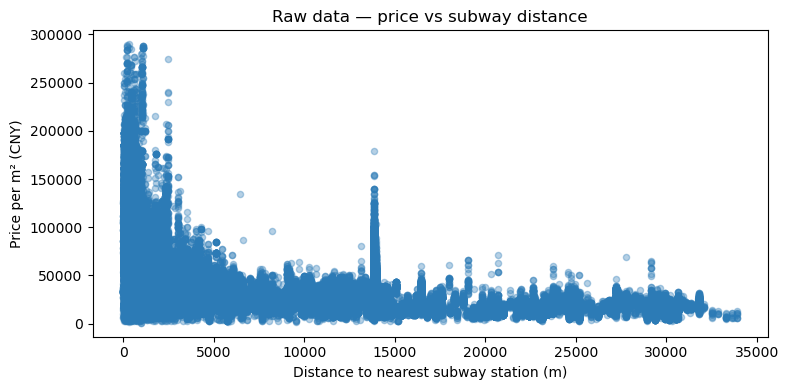

In [3]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.scatter(X, y, alpha=0.35, s=20, color="#2c7bb6")
ax.set_xlabel("Distance to nearest subway station (m)")
ax.set_ylabel("Price per m² (CNY)")
ax.set_title("Raw data — price vs subway distance")
plt.tight_layout()
plt.show()

## Step 1 · Grid Search with `np.linspace` — Coarse → Fine

We minimise the **Mean Squared Error** (MSE):

$$\text{MSE}(\beta_0, \beta_1) = \frac{1}{n}\sum_{i=1}^{n}\left(y_i - \beta_0 - \beta_1 x_i\right)^2$$

**Strategy**: search on a 2-D grid, find the best cell, shrink the grid around it, repeat.


### TODO analyse this code and paste here what it does 

here 

In [4]:
def mse(b0, b1, X, y):
    """Scalar MSE for a single (b0, b1) pair."""
    resid = y - (b0 + b1 * X)
    return np.mean(resid ** 2)

def grid_search_NOT_VECTOR(b0_range, b1_range, steps, X, y):
    """
    Evaluate MSE on a (steps × steps) grid.
    Returns best (b0, b1) and the full MSE matrix.
    """
    b0_vals = np.linspace(*b0_range, steps)
    b1_vals = np.linspace(*b1_range, steps)
 
    MSE      = np.zeros((steps, steps))   # pre-allocate result matrix
    best_mse = np.inf
    best_i   = 0
    best_j   = 0
 
    for i, b0 in enumerate(b0_vals):          # axis 0 → β₀
        for j, b1 in enumerate(b1_vals):      # axis 1 → β₁
            resid      = y - (b0 + b1 * X)   # shape (n,) — one pair at a time
            MSE[i, j]  = np.mean(resid ** 2)
            if MSE[i, j] < best_mse:
                best_mse       = MSE[i, j]
                best_i, best_j = i, j
 
    best_b0 = b0_vals[best_i]
    best_b1 = b1_vals[best_j]
    return best_b0, best_b1, b0_vals, b1_vals, MSE

### TODO analyse this code and paste here what it does 

here 

In [5]:
def mse(b0, b1, X, y):
    """Scalar MSE for a single (b0, b1) pair."""
    resid = y - (b0 + b1 * X)
    return np.mean(resid ** 2)

def grid_search(b0_range, b1_range, steps, X, y):
    """
    Evaluate MSE on a (steps × steps) grid.
    Returns best (b0, b1) and the full MSE matrix.
    """
    b0_vals = np.linspace(*b0_range, steps)
    b1_vals = np.linspace(*b1_range, steps)
    B0, B1  = np.meshgrid(b0_vals, b1_vals)          # shape (steps, steps)

    # Vectorised MSE over the whole grid
    # Expand X and y to broadcast: X shape (n,) → (1, 1, n)
    resid = y[None, None, :] - (B0[:, :, None] + B1[:, :, None] * X[None, None, :])
    MSE   = np.mean(resid ** 2, axis=2)              # shape (steps, steps)

    idx        = np.unravel_index(np.argmin(MSE), MSE.shape)
    best_b0    = B0[idx]
    best_b1    = B1[idx]
    return best_b0, best_b1, b0_vals, b1_vals, MSE

### TODO Compare both execution time with prefix values 

In [6]:
# ── Pass 1: coarse grid ──────────────────────────────────────────────────────
b0_range = (0, 300_000)
b1_range = (-100, 100)
steps    = 60
print(f'b_0 range: {b0_range}, b_1 range: {b1_range}')

b_0 range: (0, 300000), b_1 range: (-100, 100)


#### Not vector version

In [7]:
%%time
b0_c, b1_c, b0v_c, b1v_c, MSE_c = grid_search_NOT_VECTOR(b0_range, b1_range, steps, X, y)
print(f"[Coarse]  β₀ ≈ {b0_c:,.0f}  β₁ ≈ {b1_c:.2f}  MSE = {mse(b0_c, b1_c, X, y):,.0f}")

[Coarse]  β₀ ≈ 61,017  β₁ ≈ -1.69  MSE = 655,123,760
CPU times: total: 32.3 s
Wall time: 37.8 s


#### vector version

In [8]:
%%time
b0_c, b1_c, b0v_c, b1v_c, MSE_c = grid_search(b0_range, b1_range, steps, X, y)
print(f"[Coarse]  β₀ ≈ {b0_c:,.0f}  β₁ ≈ {b1_c:.2f}  MSE = {mse(b0_c, b1_c, X, y):,.0f}")

CPU times: total: 0 ns
Wall time: 19.5 ms


MemoryError: Unable to allocate 13.0 GiB for an array with shape (60, 60, 484132) and data type float64

### TODO reduce range width by 20%

In [9]:
margin = 0.20      # ±20 % of the search width → much tighter
b0_w   = (b0_range[1] - b0_range[0])*margin
b1_w   = (b1_range[1] - b1_range[0])*margin

### TODO execute pass 2 with fastest method

In [10]:
b0_m, b1_m, b0v_m, b1v_m, MSE_m = grid_search_NOT_VECTOR(
    (b0_c - b0_w, b0_c + b0_w),
    (b1_c - b1_w, b1_c + b1_w),
    steps, X, y
)
print(f"[Medium]  β₀ ≈ {b0_m:,.0f}  β₁ ≈ {b1_m:.2f}  MSE = {mse(b0_m, b1_m, X, y):,.0f}")

[Medium]  β₀ ≈ 66,102  β₁ ≈ -2.37  MSE = 635,668,336


### TODO reduce range width by 20%

In [11]:
b0_w2 =  b0_w * margin
b1_w2 = b1_w * margin

### TODO execute pass 3 with fastest method

In [12]:
b0_f, b1_f, b0v_f, b1v_f, MSE_f = grid_search_NOT_VECTOR(
    (b0_m - b0_w2, b0_m + b0_w2),
    (b1_m - b1_w2, b1_m + b1_w2),
    steps, X, y
)
print(f"[Fine]    β₀ ≈ {b0_f:,.0f}  β₁ ≈ {b1_f:.2f}  MSE = {mse(b0_f, b1_f, X, y):,.0f}")

[Fine]    β₀ ≈ 64,678  β₁ ≈ -2.24  MSE = 635,620,671


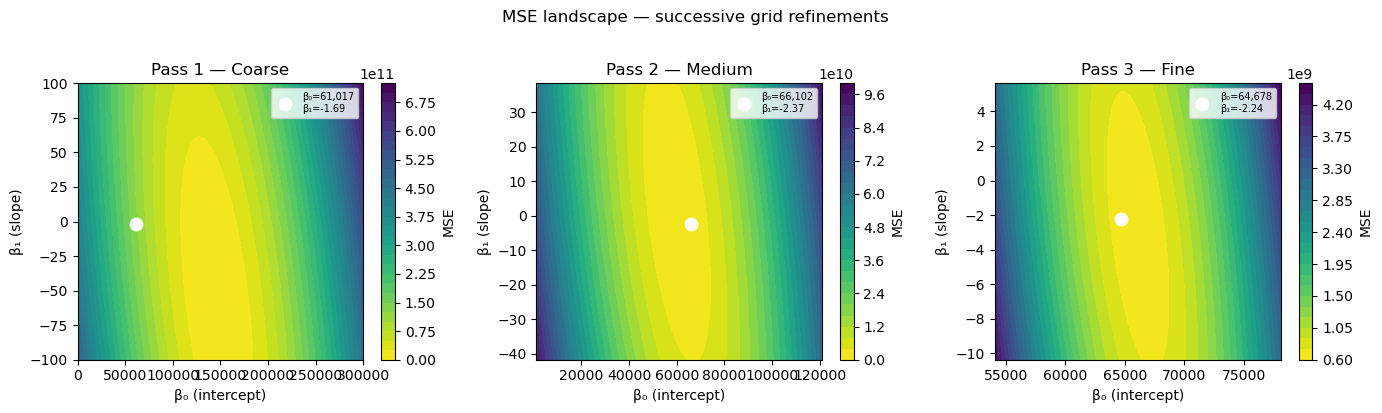


Grid-search result  →  β₀ = 64,678.0   β₁ = -2.2373


In [13]:
# ── Visualise the three grids side by side ─────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, (b0v, b1v, MSE, b0_best, b1_best, title) in zip(
    axes,
    [
        (b0v_c, b1v_c, MSE_c, b0_c, b1_c, "Pass 1 — Coarse"),
        (b0v_m, b1v_m, MSE_m, b0_m, b1_m, "Pass 2 — Medium"),
        (b0v_f, b1v_f, MSE_f, b0_f, b1_f, "Pass 3 — Fine"),
    ],
):
    cf = ax.contourf(b0v, b1v, MSE, levels=30, cmap="viridis_r")
    ax.scatter([b0_best], [b1_best], c="white", s=80, zorder=5, label=f"β₀={b0_best:,.0f}\nβ₁={b1_best:.2f}")
    ax.set_xlabel("β₀ (intercept)")
    ax.set_ylabel("β₁ (slope)")
    ax.set_title(title)
    ax.legend(fontsize=7, loc="upper right")
    plt.colorbar(cf, ax=ax, label="MSE")

plt.suptitle("MSE landscape — successive grid refinements", y=1.02)
plt.tight_layout()
plt.show()

print(f"\nGrid-search result  →  β₀ = {b0_f:,.1f}   β₁ = {b1_f:.4f}")


NameError: name 'TRUE_B0' is not defined

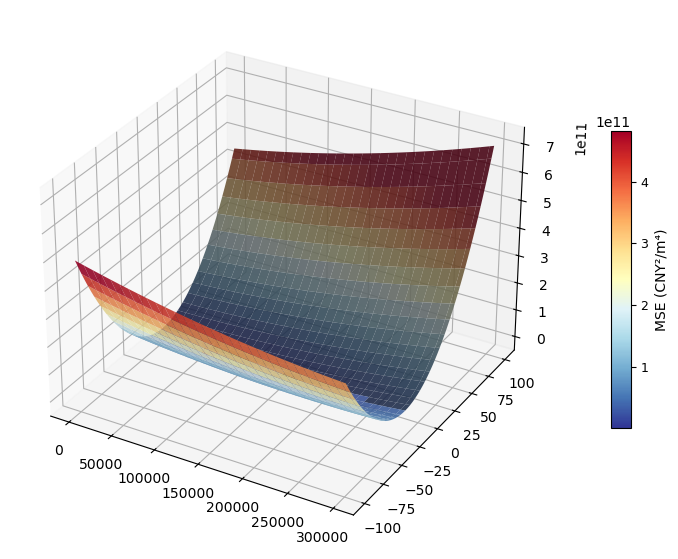

In [14]:
# ── 3D MSE surface — matplotlib ───────────────────────────────────────────────
# Drop this cell after Step 1 (grid search) in the notebook.
# Expects: b0_vals, b1_vals, MSE, best_b0, best_b1 from grid_search_VECTOR().

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib import cm
from mpl_toolkits.mplot3d import Axes3D          # noqa: F401 (registers projection)

# ── Data ──────────────────────────────────────────────────────────────────────
# Replace with your actual grid search outputs:
#   best_b0, best_b1, b0_vals, b1_vals, MSE = grid_search_VECTOR(...)
best_b0, best_b1, b0_vals, b1_vals, MSE = grid_search_NOT_VECTOR(b0_range, b1_range, steps, X, y)


B0_GRID, B1_GRID = np.meshgrid(b0_vals, b1_vals, indexing='ij')   # (s, s)
best_mse = MSE[np.unravel_index(np.argmin(MSE), MSE.shape)]

# ── Colour mapping: blue (low MSE) → yellow → red (high MSE) ─────────────────
cmap    = cm.RdYlBu_r                            # reversed: blue=low, red=high
norm    = plt.Normalize(vmin=MSE.min(), vmax=np.percentile(MSE, 95))
fcolors = cmap(norm(MSE))                        # RGBA array for plot_surface

# ── Figure ────────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(10, 7))
ax  = fig.add_subplot(111, projection='3d')

# Surface
surf = ax.plot_surface(
    B0_GRID, B1_GRID, MSE,
    facecolors=fcolors,
    antialiased=True,
    linewidth=0,
    alpha=0.88,
)

# Colourbar (mapped manually since facecolors bypasses the built-in norm)
sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, shrink=0.55, pad=0.08, aspect=15)
cbar.set_label('MSE (CNY²/m⁴)', fontsize=10)
cbar.ax.tick_params(labelsize=9)

# Grid minimum marker
ax.scatter(
    [best_b0], [best_b1], [best_mse],
    color='white', edgecolors='#d7191c', s=120, linewidths=2,
    marker='X', zorder=10, label=f'Grid min  β₀={best_b0:,.0f}  β₁={best_b1:.2f}',
)

# True parameter marker (projected onto the surface at the nearest grid cell)
i_true = np.argmin(np.abs(b0_vals - TRUE_B0))
j_true = np.argmin(np.abs(b1_vals - TRUE_B1))
ax.scatter(
    [65269.9100], [-2.3623], [MSE[i_true, j_true]],
    color='#1a9641', edgecolors='white', s=120, linewidths=1.5,
    marker='*', zorder=10, label=f'True β  β₀={TRUE_B0:,}  β₁={TRUE_B1}',
)

# ── Axes labels & formatting ──────────────────────────────────────────────────
ax.set_xlabel('β₀  (intercept, CNY/m²)', fontsize=10, labelpad=10)
ax.set_ylabel('β₁  (slope, CNY/m²/m)',   fontsize=10, labelpad=10)
ax.set_zlabel('MSE',                      fontsize=10, labelpad=8)

ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda y, _: f'{y:.1f}'))
ax.zaxis.set_major_formatter(mticker.FuncFormatter(lambda z, _: f'{z/1e6:.0f}M'))

ax.tick_params(axis='both', labelsize=8)
ax.set_title('MSE loss landscape — grid search over (β₀, β₁)',
             fontsize=12, pad=14)

# Initial viewing angle: slightly elevated, looking from the front-left
ax.view_init(elev=28, azim=-130)

ax.legend(loc='upper right', fontsize=9, framealpha=0.7)
plt.tight_layout()
plt.show()

## Step 2 · Gradient Descent

write down the partial derivative of the linear regression formula 

$$\frac{\partial \text{MSE}}{\partial \beta_0}$$

$$\frac{\partial \text{MSE}}{\partial \beta_1}$$

where $e_i = y_i - \hat{y}_i$.




In [15]:
# ── Feature standardisation — critical for stable GD ─────────────────────────
X_mean, X_std = X.mean(), X.std()
y_mean, y_std = y.mean(), y.std()

X_s = (X - X_mean) / X_std    # standardised predictor
y_s = (y - y_mean) / y_std    # standardised response

### TODO write the grad_b0 and grad_b1 using the partial derivative

### TODO try different lr (learning rate) to find a good one

### TODO explain what ou observe while changing the lr
here

In [16]:
def gradient_descent(X, y, lr, n_iter=500, init=(0.0, 0.0)):
    """
    Gradient descent on MSE loss.
    Works on standardised data.
    Returns history of (b0, b1, mse).
    """
    b0, b1 = init
    n      = len(X)
    history = []

    for _ in range(n_iter):
        y_hat = b0 + b1 * X
        resid = y - y_hat

        grad_b0 = None
        grad_b1 = None

        b0 -= lr * grad_b0
        b1 -= lr * grad_b1

        history.append((b0, b1, np.mean(resid ** 2)))

    return b0, b1, history

In [17]:
b0_s, b1_s, history = gradient_descent(X_s, y_s, lr=None, n_iter=500)

# ── Back-transform to original scale ─────────────────────────────────────────
b1_gd = b1_s * (y_std / X_std)
b0_gd = y_mean - b1_gd * X_mean

print(f"Gradient Descent  →  β₀ = {b0_gd:,.1f}   β₁ = {b1_gd:.4f}")

TypeError: unsupported operand type(s) for *: 'NoneType' and 'NoneType'

In [ ]:
# ── Convergence plot ──────────────────────────────────────────────────────────
mse_history = [h[2] for h in history]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# MSE over iterations
axes[0].plot(mse_history, color="#e34a33", lw=1.5)
axes[0].set_xlabel("Iteration")
axes[0].set_ylabel("MSE (standardised scale)")
axes[0].set_title("GD convergence — MSE")
axes[0].set_yscale("log")

# β trajectory on the loss landscape (standardised)
b0_hist = np.array([h[0] for h in history])
b1_hist = np.array([h[1] for h in history])

# Quick MSE landscape for background
b0_g = np.linspace(b0_hist.min()-0.3, b0_hist.max()+0.3, 60)
b1_g = np.linspace(b1_hist.min()-0.3, b1_hist.max()+0.3, 60)
B0g, B1g = np.meshgrid(b0_g, b1_g)
MSEg = np.mean(
    (y_s[None, None, :] - (B0g[:,:,None] + B1g[:,:,None] * X_s[None, None, :]))**2,
    axis=2
)
axes[1].contourf(b0_g, b1_g, MSEg, levels=30, cmap="YlOrRd_r")
axes[1].plot(b0_hist, b1_hist, "o-", color="white", ms=2, lw=0.8, alpha=0.7)
axes[1].scatter([b0_hist[-1]], [b1_hist[-1]], c="cyan", zorder=5, s=60, label="Converged")
axes[1].scatter([b0_hist[0]],  [b1_hist[0]],  c="lime",  zorder=5, s=60, label="Start")
axes[1].set_xlabel("β₀ (std. scale)")
axes[1].set_ylabel("β₁ (std. scale)")
axes[1].set_title("GD trajectory on MSE landscape")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()


## Step 3 · From Residuals to Inference

We now pick our best estimates (use GD result) and derive the full inference chain.

### 3.1 — Residuals and Standard Error of the Regression
$$\hat{e}_i = y_i - \hat{y}_i \qquad
s = \sqrt{\frac{\sum \hat{e}_i^2}{n-2}}$$

### 3.2 — Standard Errors of the Coefficients
$$SE(\hat{\beta}_1) = \frac{s}{\sqrt{\sum(x_i - \bar{x})^2}} \qquad
SE(\hat{\beta}_0) = s\sqrt{\frac{1}{n} + \frac{\bar{x}^2}{\sum(x_i-\bar{x})^2}}$$

### 3.3 — t-statistics and p-values
$$t_{\beta_k} = \frac{\hat{\beta}_k}{SE(\hat{\beta}_k)} \sim t_{n-2}$$


In [ ]:
# ── Use GD coefficients (you could swap b0_f / b1_f from grid search) ──
b0_hat, b1_hat = b0_gd, b1_gd

y_hat = b0_hat + b1_hat * X          # fitted values
resid = y - y_hat                    # residuals

### TODO write down RSS formula, standard devisation formula

In [ ]:
# ── 3.1 · Residual standard error ─────────────────────────────────────────────
df    = n - 2                        # degrees of freedom
RSS   = None           # residual sum of squares
s     = None            # σ̂  (std error of regression)

print(f"RSS  = {RSS:,.0f}")
print(f"σ̂   = {s:,.2f}  (std error of regression, n-2={df} df)")

### TODO write down Sxx formula, SEs

In [ ]:
# ── 3.2 · SE of coefficients ──────────────────────────────────────────────────
Sxx      = None   # Σ(xᵢ - x̄)²

se_b1    = None
se_b0    = None

print(f"\nSE(β₁) = {se_b1:.6f}")
print(f"SE(β₀) = {se_b0:.2f}")

### TODO write down t statistic for b0 and b1

In [ ]:
# ── 3.3 · t-statistics ────────────────────────────────────────────────────────
t_b0 = None
t_b1 = None

print(f"\nt(β₀) = {t_b0:.4f}")
print(f"t(β₁) = {t_b1:.4f}")

### TODO explain what `stats.t.sf` function does

here

In [ ]:
# ── 3.4 · p-values (two-tailed, t distribution with n-2 df) ──────────────────
p_b0 = 2 * stats.t.sf(np.abs(t_b0), df=df)
p_b1 = 2 * stats.t.sf(np.abs(t_b1), df=df)

print(f"\np(β₀) = {p_b0:.2e}")
print(f"p(β₁) = {p_b1:.2e}")

### TODO explain what `stats.t.ppf` function does

here

In [ ]:
# ── 3.5 · 95 % Confidence Intervals ──────────────────────────────────────────
t_crit = stats.t.ppf(0.975, df=df)
ci_b0  = (b0_hat - t_crit * se_b0, b0_hat + t_crit * se_b0)
ci_b1  = (b1_hat - t_crit * se_b1, b1_hat + t_crit * se_b1)

print(f"\n95% CI β₀: [{ci_b0[0]:,.1f}, {ci_b0[1]:,.1f}]")
print(f"95% CI β₁: [{ci_b1[0]:.4f}, {ci_b1[1]:.4f}]")

### TODO write down the 99% ci interval code

In [ ]:
# ── 3.5 · 99 % Confidence Intervals ──────────────────────────────────────────


In [ ]:
# ── Summary table ─────────────────────────────────────────────────────────────
import warnings
warnings.filterwarnings("ignore")

summary = pd.DataFrame({
    "Coefficient": ["β₀ (Intercept)", "β₁ (dist_subway_m)"],
    "Estimate":    [round(b0_hat, 2),  round(b1_hat, 4)],
    "Std. Error":  [round(se_b0, 2),   round(se_b1, 6)],
    "t-value":     [round(t_b0, 4),    round(t_b1, 4)],
    "p-value":     [f"{p_b0:.3e}",     f"{p_b1:.3e}"],
    "95% CI low":  [round(ci_b0[0],1), round(ci_b1[0],4)],
    "95% CI high": [round(ci_b0[1],1), round(ci_b1[1],4)],
})
summary.set_index("Coefficient", inplace=True)
display(summary)


### TODO calculate TSS Total Sum of Squares — the total variance in y before any model is fitted.

### TODO calculate R2 that is what fraction of the total variance did the model explain?

In [ ]:
# ── R² ────────────────────────────────────────────────────────────────────────
TSS  = None
R2   = 1 - None
adjR2 = 1 - (1 - R2) * (n - 1) / (n - 2)
print(f"R²        = {R2:.4f}")
print(f"Adj. R²   = {adjR2:.4f}")
print(f"F-stat    = {(R2 / 1) / ((1 - R2) / (n - 2)):.2f}  (p ≈ {stats.f.sf((R2/1)/((1-R2)/(n-2)), 1, n-2):.2e})")


## Step 4 · Diagnostic Plots

| Plot | What to look for |
|------|-----------------|
| **Residuals vs Fitted** | Random scatter around 0 → linearity & homoscedasticity ✓ |
| **Scale-Location** | Flat red line → constant variance (homoscedasticity) |
| **Residuals histogram** | Bell-shape → normality of errors |
| **Q-Q plot** | Points on diagonal → normality |


In [ ]:
fig = plt.figure(figsize=(14, 10))
gs  = gridspec.GridSpec(2, 2, hspace=0.4, wspace=0.35)

# ── (A) Residuals vs Fitted ───────────────────────────────────────────────────
ax0 = fig.add_subplot(gs[0, 0])
ax0.scatter(y_hat, resid, alpha=0.35, s=18, color="#2c7bb6")
ax0.axhline(0, color="red", lw=1.5, ls="--")

# Lowess smoother for trend
from scipy.ndimage import uniform_filter1d
sort_idx  = np.argsort(y_hat)
smoothed  = uniform_filter1d(resid[sort_idx], size=30)
ax0.plot(y_hat[sort_idx], smoothed, color="orange", lw=2, label="Trend (smoothed)")

ax0.set_xlabel("Fitted values  ŷ")
ax0.set_ylabel("Residuals  eᵢ")
ax0.set_title("(A) Residuals vs Fitted")
ax0.legend(fontsize=8)

# ── (B) Scale-Location (√|e| vs fitted) ───────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 1])
sqrt_abs_resid = np.sqrt(np.abs(resid))
ax1.scatter(y_hat, sqrt_abs_resid, alpha=0.35, s=18, color="#fdae61")
smoothed2 = uniform_filter1d(sqrt_abs_resid[sort_idx], size=30)
ax1.plot(y_hat[sort_idx], smoothed2, color="red", lw=2)
ax1.set_xlabel("Fitted values  ŷ")
ax1.set_ylabel("√|Residuals|")
ax1.set_title("(B) Scale-Location")

# ── (C) Histogram of residuals ────────────────────────────────────────────────
ax2 = fig.add_subplot(gs[1, 0])
ax2.hist(resid, bins=30, color="#abd9e9", edgecolor="white", density=True)

# Overlay normal fit
mu_e, sigma_e = resid.mean(), resid.std()
x_norm = np.linspace(resid.min(), resid.max(), 200)
ax2.plot(x_norm, stats.norm.pdf(x_norm, mu_e, sigma_e), "r-", lw=2, label="Normal fit")
ax2.axvline(0, color="gray", ls="--", lw=1)
ax2.set_xlabel("Residual")
ax2.set_ylabel("Density")
ax2.set_title("(C) Residual distribution")
ax2.legend(fontsize=8)

# ── (D) Normal Q-Q plot ───────────────────────────────────────────────────────
ax3 = fig.add_subplot(gs[1, 1])
(osm, osr), (slope_qq, intercept_qq, _) = stats.probplot(resid, dist="norm")
ax3.scatter(osm, osr, alpha=0.35, s=18, color="#2c7bb6")
qqx = np.array([min(osm), max(osm)])
ax3.plot(qqx, slope_qq * qqx + intercept_qq, "r--", lw=1.5, label="Theoretical")
ax3.set_xlabel("Theoretical quantiles")
ax3.set_ylabel("Sample quantiles")
ax3.set_title("(D) Normal Q-Q")
ax3.legend(fontsize=8)

plt.suptitle("Regression Diagnostics — Price ~ Distance to Subway", fontsize=13, y=1.01)
plt.show()

# ── Shapiro-Wilk normality test ───────────────────────────────────────────────
stat_sw, p_sw = stats.shapiro(resid[:500] if n > 500 else resid)
print(f"Shapiro-Wilk  W = {stat_sw:.4f}   p = {p_sw:.4f}")
print("→ Residuals appear normal." if p_sw > 0.05 else "→ Residuals may deviate from normality.")


### TODO what do you observe in 
A- __residuals vs fitted__: 

B- __scale location__:

C- __Residual distribution__:

D- __normal QQ__:

### TODO what is your conclusion


## Step 5 · Verification with `statsmodels`

Now compare your manual results with the OLS reference.


In [ ]:
import statsmodels.api as sm

X_sm  = sm.add_constant(X)           # adds a column of 1s for the intercept
model = sm.OLS(y, X_sm).fit()

print(model.summary())


In [ ]:
# ── Side-by-side comparison ────────────────────────────────────────────────────
compare = pd.DataFrame({
    "": ["β₀ (intercept)", "β₁ (slope)"],
    "Manual (GD)":      [round(b0_gd, 2),        round(b1_gd, 4)],
    "Grid Search":      [round(b0_f, 2),          round(b1_f, 4)],
    "statsmodels OLS":  [round(model.params[0],2), round(model.params[1],4)]
}).set_index("")
display(compare)



## Key Takeaways

1. **Grid search** is intuitive but expensive: cost grows as `steps² × n`.
   Successive refinement drastically cuts the search space.
2. **Gradient Descent** scales to millions of rows and generalises to
   multi-variate / regularised regression.  Standardising features first is
   essential for convergence.
3. **Standard errors** quantify how uncertain our coefficient estimates are.
   They depend on both the noise level *s* and the spread of X (Sxx).
4. The **t-statistic** tells us how many SEs away from zero our estimate is;
   the **p-value** translates that to a probability under H₀: β = 0.
5. **Diagnostic plots** validate OLS assumptions:
   - Residuals vs Fitted → linearity & equal variance
   - Q-Q / histogram → normality of errors

A significant β₁ here confirms that proximity to the subway has a measurable
effect on price per m² — consistent with urban economics theory.
